# 04 — Report Artifacts: Tables and Figures

This notebook consolidates the final **tables** and **figures** used in the Model Validation Report.
Artifacts are generated by the reproducible runner `scripts/05_generate_report_artifacts.py` and stored under:

- `reports/tables/`
- `reports/figures/`

The goal here is to:
- verify artifact completeness and consistency
- preview all report-ready visuals and tables
- provide an ordered set of inputs for the final PDF report

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path("..").resolve()
TABLES_DIR = PROJECT_ROOT / "reports" / "tables"
FIGURES_DIR = PROJECT_ROOT / "reports" / "figures"

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 200)

print("Tables dir:", TABLES_DIR)
print("Figures dir:", FIGURES_DIR)

Tables dir: /Users/noelp/PycharmProjects/model-risk-validation-pd-lgd-ead/reports/tables
Figures dir: /Users/noelp/PycharmProjects/model-risk-validation-pd-lgd-ead/reports/figures


## Artifact inventory

The following artifacts are expected:

### Tables
- `model_summary_train_oot.csv`
- `oot_compare_champion_vs_challenger.csv`
- `score_stability_compare.csv`
- `psi_table.csv`
- `sensitivity_table.csv`
- `stress_table.csv`
- `lgd_by_grade.csv`

### Figures
- `champion_reliability_train.png`
- `champion_reliability_oot.png`
- `champion_score_hist_train_vs_oot.png`
- `psi_top_drivers.png`
- `challenger_shap_bar.png`

In [2]:
expected_tables = [
    "model_summary_train_oot.csv",
    "oot_compare_champion_vs_challenger.csv",
    "score_stability_compare.csv",
    "psi_table.csv",
    "sensitivity_table.csv",
    "stress_table.csv",
    "lgd_by_grade.csv",
]

expected_figures = [
    "champion_reliability_train.png",
    "champion_reliability_oot.png",
    "champion_score_hist_train_vs_oot.png",
    "psi_top_drivers.png",
    "challenger_shap_bar.png",
]

missing_tables = [f for f in expected_tables if not (TABLES_DIR / f).exists()]
missing_figures = [f for f in expected_figures if not (FIGURES_DIR / f).exists()]

print("Missing tables:", missing_tables)
print("Missing figures:", missing_figures)

Missing tables: []
Missing figures: []


## Performance and calibration summary (Train vs OOT)

This table supports:
- Champion validation evidence (Train vs OOT)
- Challenger benchmark evidence (Train vs OOT)
- calibration diagnostics (slope/intercept, Mean_PD vs observed default rate)

In [3]:
summary = pd.read_csv(TABLES_DIR / "model_summary_train_oot.csv")
summary

,model,set,AUC,PR_AUC,Gini,KS,Brier,Top10pct_Default_Capture,Mean_PD,Obs_Default_Rate,Calib_Intercept,Calib_Slope
0,Champion_Logit,Train,0.7104,0.3824,0.4208,0.3048,0.1485,0.2252,0.2067,0.2067,-0.0005,0.9996
1,Champion_Logit,OOT,0.6973,0.2631,0.3947,0.2939,0.1213,0.2092,0.1906,0.1473,-0.5420,0.8370
2,Challenger_LGBM,Train,0.7318,0.4155,0.4635,0.3368,0.1448,0.2421,0.2067,0.2067,0.0915,1.0790
3,Challenger_LGBM,OOT,0.7262,0.3038,0.4525,0.3372,0.1183,0.2411,0.1968,0.1473,-0.4185,0.9739


## Out-of-time (OOT) comparison: Champion vs Challenger

This table supports the decision section:
- discrimination improvement (AUC/KS/PR-AUC, Top10% capture)
- probability quality (Brier, calibration slope/intercept)
- probability level (Mean_PD vs observed default rate)

In [4]:
oot_compare = pd.read_csv(TABLES_DIR / "oot_compare_champion_vs_challenger.csv")
oot_compare

,model,AUC,PR_AUC,KS,Brier,Top10pct_Default_Capture,Mean_PD,Obs_Default_Rate,Calib_Intercept,Calib_Slope
0,Champion_Logit,0.6973,0.2631,0.2939,0.1213,0.2092,0.1906,0.1473,-0.5420,0.8370
1,Challenger_LGBM,0.7262,0.3038,0.3372,0.1183,0.2411,0.1968,0.1473,-0.4185,0.9739


## Score stability comparison (Train → OOT)

This table supports monitoring recommendations:
- score PSI (distribution drift magnitude)
- score KS shift (distribution drift effect size)

In [5]:
score_stab = pd.read_csv(TABLES_DIR / "score_stability_compare.csv")
score_stab

,model,score_psi,score_ks_stat,score_ks_p
0,Champion_Logit,0.025877,0.057605,0.0
1,Challenger_LGBM,0.015908,0.044408,0.0


## PSI monitoring table (Champion inputs + score)

This table is monitoring-ready:
- top drift drivers (AMBER/RED)
- score drift (pd_pred)

In [6]:
psi_table = pd.read_csv(TABLES_DIR / "psi_table.csv")
psi_table.head(20)

,feature,type,psi,flag
0,revol_util,numeric,0.2902,RED
1,application_type,categorical,0.2457,AMBER
2,int_rate,numeric,0.1271,AMBER
3,revol_bal,numeric,0.0881,GREEN
4,purpose,categorical,0.0783,GREEN
5,sub_grade,categorical,0.0756,GREEN
6,funded_amnt,numeric,0.0625,GREEN
7,loan_amnt,numeric,0.0625,GREEN
8,verification_status,categorical,0.0456,GREEN
9,dti,numeric,0.0432,GREEN


In [7]:
# Top drift drivers
psi_table.sort_values("psi", ascending=False).head(15)

,feature,type,psi,flag
0,revol_util,numeric,0.2902,RED
1,application_type,categorical,0.2457,AMBER
2,int_rate,numeric,0.1271,AMBER
3,revol_bal,numeric,0.0881,GREEN
4,purpose,categorical,0.0783,GREEN
5,sub_grade,categorical,0.0756,GREEN
6,funded_amnt,numeric,0.0625,GREEN
7,loan_amnt,numeric,0.0625,GREEN
8,verification_status,categorical,0.0456,GREEN
9,dti,numeric,0.0432,GREEN


## Sensitivity results (OOT)

This table supports robustness assessment:
- PD level sensitivity (mean and p95)
- ranking stability (Spearman correlation)

In [8]:
sens = pd.read_csv(TABLES_DIR / "sensitivity_table.csv")
sens

,feature,shock,mean_pd_base,mean_pd_new,delta_mean_pd,p95_base,p95_new,delta_p95,spearman_rank_corr
0,annual_inc,-0.10,0.190617,0.192223,0.001606,0.417995,0.420332,0.002337,0.999958
1,annual_inc,-0.05,0.190617,0.191418,0.000801,0.417995,0.419096,0.001101,0.999989
2,annual_inc,0.05,0.190617,0.189820,-0.000797,0.417995,0.416774,-0.001222,0.999990
3,annual_inc,0.10,0.190617,0.189027,-0.001591,0.417995,0.415630,-0.002365,0.999959
4,dti,-0.10,0.190617,0.186945,-0.003673,0.417995,0.410241,-0.007754,0.999867
5,dti,-0.05,0.190617,0.188775,-0.001842,0.417995,0.414109,-0.003886,0.999967
6,dti,0.05,0.190617,0.192470,0.001853,0.417995,0.422023,0.004028,0.999968
7,dti,0.10,0.190617,0.194335,0.003717,0.417995,0.425906,0.007911,0.999872
8,revol_util,-0.10,0.190617,0.190006,-0.000611,0.417995,0.416765,-0.001231,0.999995
9,revol_util,-0.05,0.190617,0.190311,-0.000306,0.417995,0.417401,-0.000595,0.999999


## Stress scenarios and Expected Loss proxy

This table supports scenario-based vulnerability assessment:
- PD mean and tail shifts under stress
- EL proxy shift under stress

In [9]:
stress = pd.read_csv(TABLES_DIR / "stress_table.csv")
stress

,scenario,mean_pd,delta_mean_pd,p95_pd,delta_p95,EL_proxy_mean,delta_EL_proxy,LGD_avg_defaults
0,mild,0.195145,0.004528,0.427175,0.009180,647.706794,13.718138,0.979338
1,severe,0.200342,0.009725,0.436968,0.018973,663.375656,29.387000,0.979338


## LGD proxy by grade (defaults only)

This table supports the loss decomposition narrative:
- LGD proxy distribution by grade
- limitations documented in the report (proxy nature, recoveries behavior)

In [10]:
lgd = pd.read_csv(TABLES_DIR / "lgd_by_grade.csv")
lgd

,grade,count,mean,median,p90
0,C,2128,0.980893,1.0,1.0
1,D,1974,0.977382,1.0,1.0
2,B,1402,0.981952,1.0,1.0
3,E,707,0.974824,1.0,1.0
4,A,519,0.983331,1.0,1.0
5,F,175,0.971131,1.0,1.0
6,G,46,0.967148,1.0,1.0


## Figures overview

The following figures provide the main visual evidence:
- calibration quality (reliability curves)
- score distribution shift
- drift drivers (PSI bar plot)
- challenger interpretability (SHAP bar plot)

In [20]:
import matplotlib.image as mpimg

def show_png(path: Path, title: str):
    img = mpimg.imread(path)
    plt.figure(figsize=(10, 6))
    plt.imshow(img)
    plt.axis("off")
    plt.show()

## Calibration figures (Champion)

These plots support calibration findings:
- Train: near-diagonal calibration
- OOT: systematic deviation consistent with calibration drift

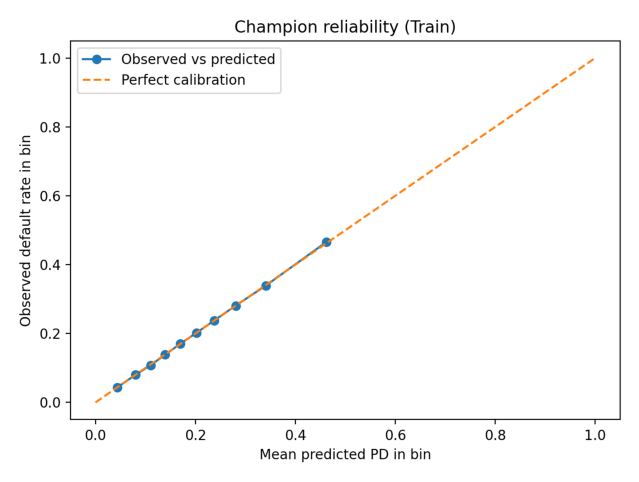

In [21]:
show_png(FIGURES_DIR / "champion_reliability_train.png", "Champion reliability (Train)")

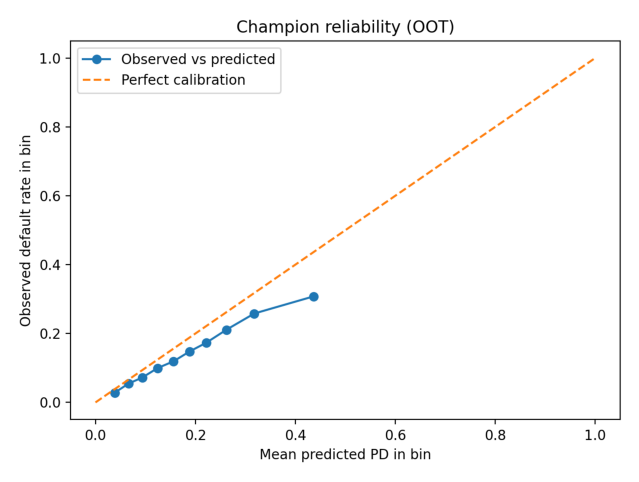

In [22]:
show_png(FIGURES_DIR / "champion_reliability_oot.png", "Champion reliability (OOT)")

## Score distribution shift (Champion)

This figure supports drift evidence on the model output distribution.

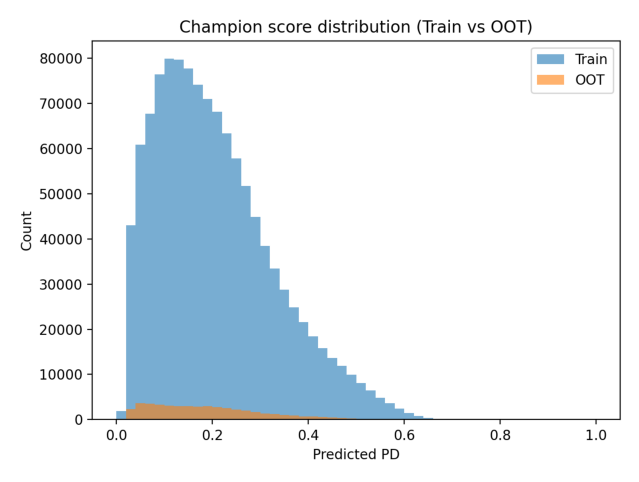

In [23]:
show_png(FIGURES_DIR / "champion_score_hist_train_vs_oot.png", "Champion score distribution (Train vs OOT)")

## Top PSI drift drivers

This figure supports monitoring prioritization:
- identify highest-drift inputs (and score)
- translate drift into monitoring triggers

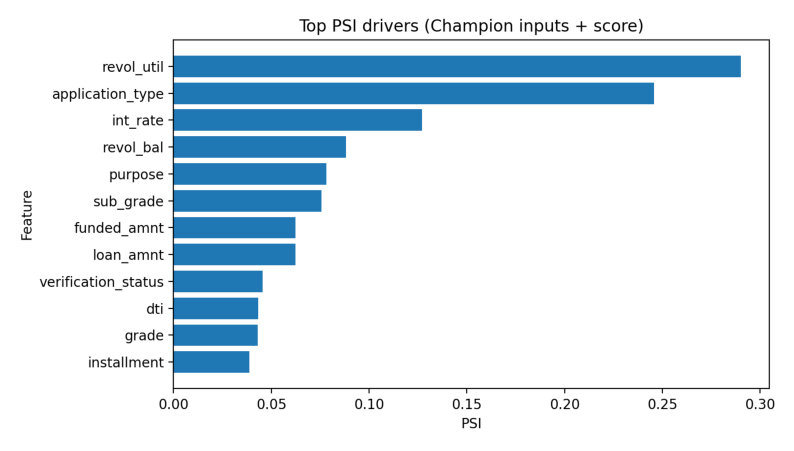

In [24]:
show_png(FIGURES_DIR / "psi_top_drivers.png", "Top PSI drivers (Champion inputs + score)")

## Challenger interpretability (SHAP)

This figure supports the challenger governance narrative:
- global drivers align with credit intuition
- no leakage-type fields among top drivers

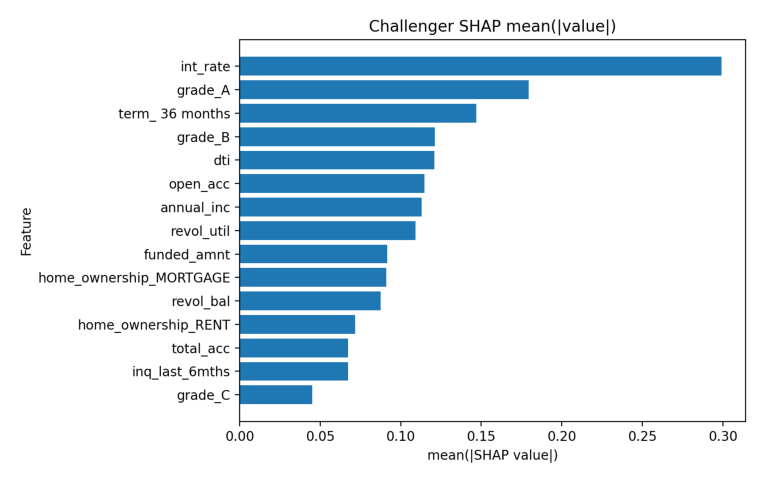

In [25]:
show_png(FIGURES_DIR / "challenger_shap_bar.png", "Challenger SHAP mean(|value|)")